# Project A2: Predicting Housing Prices in Cook County

## Introduction

In Project A1, we performed some basic Exploratory Data Analysis (EDA), laying out the thought process that leads to certain modeling decisions. Then, added a few new features to the dataset and cleaned the data.

In this project, we will specify and fit a linear model to a few features of the housing data to predict home prices. Then, we will analyze the error of the model and brainstorm ways to improve the model's performance. Finally, we'll think about the implications of predictive modeling within the Cook County Assessor's Office (CCAO) case study. This is especially relevant because statistical modeling is how the CCAO valuates properties. 

Given the history of racial discrimination in housing policy and property taxation in Cook County, consider the impacts of the modeling results as working through this project, and think about what fairness might mean to property owners in Cook County.

In [2]:
import numpy as np

import pandas as pd
from pandas.api.types import CategoricalDtype

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model as lm

import warnings
warnings.filterwarnings("ignore")

import zipfile
import os

from ds100_utils import *
from feature_func import *

# Plot settings
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.size'] = 12

Let's load the training, validation, and test data.

In [3]:
with zipfile.ZipFile('cook_county_data.zip') as item:
    item.extractall()

The dataset is split into a training set, a validation set, and a test set. In this project, we will train and validate a model using the training and validation sets, and then use a model trained on the combined training and validation sets to predict the **logarithm (log)** of `Sale Price`s from the test set.

Importantly, the test set does **not** contain the values of our target variable, **log**(`Sale Price`). This test set can only be used to generate predictions.

In the cell below, we load the training and validation sets into the `DataFrame` `training_val_data` and the test set into the `DataFrame` `test_data`.

> The reason for predicting **log(sale price)** instead of the sale price itself: In Project A1, we added the `Log Sale Price` column, which is the logarithm of the sale price column, to neutralize the impact of extreme right-skewed outliers on the fitted model. 
>
> However, even if the model fits well by accurately predicting the log sale price, that does **not** mean it will always perform well after exponentiating the prediction back to actual sale price. Here's a simple example to illustrate this:
>
> Let’s say the dataset of actual sale prices is { $e^0 = \$1$, $e^{10} \approx \$22,000$ }. In other words, we have one home worth $\$1$, and another home worth $\$22,000$.
>
> Suppose we train a constant model on log prices using MSE. The log prices are { $\log(e^0) = 0$, $\log(e^{10}) = 10$}.
>
> The model that would best predict the log prices {0, 10} will always output a log sale price of 5 (i.e., the average of 0 and 10). In other words, the model will always output a raw price of $e^5 \approx \$148$.
>
> Even though this model has minimized error on **log** prices, it has not minimized error on **actual** prices. If we predict $\$148$, we have a huge error on the home worth $\$22,000$!
>
> If we wanted to minimize error on actual prices, we should train the model on actual prices. If we were to train a constant model on actual prices, it would always predict $\frac{1+22000}{2} \approx 11000$.
>
> For the sake of accurately evaluating the model, we will be testing your predictions against the **log** of sale prices, rather than exponentiating them and comparing to the raw sale prices.
>
> That being said, we can still convert the predicted log sale price to the sale price to gain some intuition about the model and dataset, which we will explore in later sections.

In [4]:
training_val_data = pd.read_csv("cook_county_train_val.csv", index_col='Unnamed: 0')
test_data = pd.read_csv("cook_county_contest_test.csv", index_col='Unnamed: 0')

As a good sanity check, verify that the shape of the data matches the description.

In [5]:
# 204792 observations and 62 features in training data
assert training_val_data.shape == (204792, 62)

# 55311 observations and 61 features in test data
assert test_data.shape == (55311, 61)

# Sale Price is provided in the training/validation data
assert 'Sale Price' in training_val_data.columns.values

# Sale Price and Log Sale Price is hidden in the test data
assert 'Sale Price' not in test_data.columns.values
assert 'Log Sale Price' not in test_data.columns.values

Next, we print the columns in the dataset. 

> Remember, a more detailed description of each variable is included in `codebook.txt`, which is in the same directory as this notebook. 

In [6]:
training_val_data.columns.values

<StringArray>
[                       'PIN',             'Property Class',
          'Neighborhood Code',           'Land Square Feet',
                  'Town Code',                 'Apartments',
              'Wall Material',              'Roof Material',
                   'Basement',            'Basement Finish',
            'Central Heating',              'Other Heating',
                'Central Air',                 'Fireplaces',
                 'Attic Type',               'Attic Finish',
                'Design Plan',          'Cathedral Ceiling',
       'Construction Quality',          'Site Desirability',
              'Garage 1 Size',          'Garage 1 Material',
        'Garage 1 Attachment',              'Garage 1 Area',
              'Garage 2 Size',          'Garage 2 Material',
        'Garage 2 Attachment',              'Garage 2 Area',
                      'Porch',         'Other Improvements',
       'Building Square Feet',           'Repair Condition',
          

<!-- BEGIN QUESTION -->

<br/>
<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## 1. Human Context and Ethics

In this part of the project, we will explore the human context of the housing dataset. 
<br>

--- 

### Different Parties Interested in the Housing Price

- The CCAO will be interested in the people's house worth as this assesment is the stardard metric to assign property tax. They don't care seeing a low or high housing price, more so making an accurate and fair prediction so it's close to the actual market worth. 

- Low income people will be interested in their house worth, hoping their house to be undervalued during the assessment. The under-evaluation will lead to low property tax while overestimate of their house evaluation might lead them not being able to pay the rent and lose a house.

- High income people will be interested in their house worth, also hoping underestimate of property value. If the house evaluation doesn't match their expecation, a lot of them would challenge the assessment to reduce their property tax and often succeed in doing so

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

--- 

### Interpret Unfairness in Housing Price Evaluation

The followings are different scenarios of unfair evaluation

A. A homeowner whose home is assessed at a higher price than it would sell for.  

B. A homeowner whose home is assessed at a lower price than it would sell for. 

C. An assessment process that systematically overvalues inexpensive properties and undervalues expensive properties.  

D. An assessment process that systematically undervalues inexpensive properties and overvalues expensive properties.

Scenario C is most unfair because even with the same degree of overvaluation and undervaluation, the real life impact is different based on the income background. The inexpensive properties are mostly held by low income people where the systematic overvaluation of their property would be lifechanging such as losing house. The expensive properties are mostly held by high income people where the systematic undervaluation of their property would also cause lifechanging impact to the lower income. Because additional tax burden would fall into the hands of the low income, again potentionaly losing house.

<!-- END QUESTION -->

<br>

---

### Identifying Regressive Model from Residual Plot

Consider a model fit to $n = 50$ training observations. 

We denote the response as $y$ (Log Sale Price), the prediction as $\hat{y}$, and the corresponding residual as $y - \hat{y}$. Assume that all three plots use the same vertical scale and that the horizontal line marks $y - \hat{y} = 0$. 

When a model overvalues a property (predicts a `Sale Price` greater than the actual `Sale Price`), $y < \hat{y}$ and thus the residuals are negative. When a model undervalues a property (predicts a `Sale Price` greater than the actual `Sale Price`), $y > \hat{y}$ and thus the residuals are positive.

In the residual plot A, the residuals get more positive as the sales price grows. In other words, the model undervalues expensive properties. Also, the residuals get more negative as the sales prices descrease. In other words, the model overvalues inexpensive properties

Thus, amongst the three residual plots, "A" corresponds to a model that makes property assessments resulting in **regressive** taxation. Recall that regressive taxation overvalues inexpensive properties and undervalues expensive properties. 

The residual plots "B" and "C" correspond to proportional tax and progressive tax respectively.

<img src='images/res_plots.png' width="900px" />

### The CCAO Dataset

We'll work with the dataset from the Cook County Assessor's Office (CCAO) in Illinois. This government institution determines property taxes across most of Chicago's metropolitan areas and nearby suburbs. In the United States, all property owners must pay property taxes, which are then used to fund public services, including education, road maintenance, and sanitation. These property tax assessments are based on property values estimated using statistical models considering multiple factors, such as real estate value and construction cost.

However, this system is not without flaws. In late 2017, a lawsuit was filed against the office of Cook County Assessor Joseph Berrios for producing "[racially discriminatory assessments and taxes](https://www.chicagotribune.com/politics/ct-cook-county-board-assessor-berrios-met-20170718-story.html)." The lawsuit included claims that the assessor's office undervalued high-priced homes and overvalued low-priced homes, creating a visible divide along racial lines. Wealthy homeowners, who were typically white, paid less in property taxes, whereas [working-class, non-white homeowners paid more](https://www.chicagotribune.com/news/breaking/ct-cook-county-assessor-berrios-sued-met-20171214-story.html).

The Chicago Tribune's four-part series, "[The Tax Divide](https://www.chicagotribune.com/investigations/ct-tax-divide-investigation-20180425-storygallery.html)," delves into how this was uncovered. After "compiling and analyzing more than 100 million property tax records from the years 2003 through 2015, along with thousands of pages of documents, then vetting the findings with top experts in the field," they discovered that "residential assessments had been so far off the mark for so many years." More about their investigation [here](https://apps.chicagotribune.com/news/watchdog/cook-county-property-tax-divide/assessments.html).

<!-- BEGIN QUESTION -->

<br>

--- 

### Primary Problems with the Earlier Property Tax System 

- The central problems were not being transparent tax system that led to loss of public trust

- Also, the regressive tax system that would disproportionately put more burden on the lower income and vulnerable population. 

- The primary cause was the curruption of Cook County's tax department

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

--- 

### More on Unfair Property Tax System in Cook County

In addition to being regressive, property tax system in Cook County placed a disproportionate tax burden on non-white property owners in other ways too.

- One of the underlying causes were the corrupted relation between the Cook County and the tax laywer's corporate, which made  porperty evaulation challenge system very unfair. 

- The white and rich demographics can hire the tax lawyer and successfully challenge their property assessment to lower down their property tax burden. But the nonwhite and low income demographics can't afford to hire, forcing them to accept most of the overvaluation or be unsuccessful on their challenges. 

- These combined to proportionally increase tax burden on the vulnerable population.

<!-- END QUESTION -->

<br>

<hr style="border: 1px solid #fdb515;" />

## 2. Preparing Data


We will next split the dataset into a training set and a validation set. We will use the training set to fit our model's parameters and the validation set to evaluate how well our model will perform on unseen data drawn from the same distribution as the training set. 

> If we used all the data to fit our model, we would not have a way to estimate model performance on **unseen data** such as the test set in `cook_county_contest_test.csv`.

The helper function `train_val_split` splits `data` into two smaller `DataFrame`s named `train` and `validation`. Let `train` contain 80% of the data, and let `validation` contain the remaining 20%. 

In [7]:
# This makes the train-validation split in this section reproducible across different runs 
# of the notebook. 

np.random.seed(1337)

def train_val_split(data):
    """ 
    Takes in a DataFrame `data` and randomly splits it into two smaller DataFrames 
    named `train` and `validation` with 80% and 20% of the data, respectively. 
    """
    
    data_len = data.shape[0]
    shuffled_indices = np.random.permutation(data_len)
    split_point = int(data_len * 0.8)
    train_indices = shuffled_indices[:split_point]
    validation_indices = shuffled_indices[split_point:]
    train = data.iloc[train_indices]
    validation = data.iloc[validation_indices]
   
    return train, validation
train, validation = train_val_split(training_val_data)

<br>

<hr style="border: 1px solid #fdb515;" />

## 3. Fitting a Simple Model

Let's fit a linear regression model using the ordinary least squares (OLS) estimator. We will start with a simple model that uses only two features: the **number of bathrooms** in the household and the **log-transformed total area covered by the building** (in square feet). 

Consider the following expression for the first linear model that contains one of the features:

$$
\text{Log Sale Price} = \theta_0 + \theta_1 \cdot (\text{Bathrooms})
$$

In parallel, we will also consider a second model that contains both features:

$$
\text{Log Sale Price} = \theta_0 + \theta_1 \cdot (\text{Bathrooms}) + \theta_2 \cdot (\text{Log Building Square Feet})
$$

<br>

--- 

### Comparing Training Loss Between Two Simple Models

We quantify the loss on the linear models using MSE (Mean Squared Error). Consider the training loss of the first model and the training loss of the second model. If we use normal equations to obtain the optimal set of parameters, we are guaranteed that:

$$
\text{Training Loss of the 1st Model} ~~  >= ~~ \text{Training Loss of the 2nd Model}
$$

<br>

### Pipeline Function

In Project A1, we wrote a few functions that added features to the dataset. Instead of calling them manually one by one, it is best practice to encapsulate all of this feature engineering into one "pipeline" function. Pipelines reduce all the feature engineering to just one function call and ensures that the same transformations are applied to all data.  

Below, we combined some functions into a single helper function that outputs `X` and `Y` for the first model above. 

**Note 1:** We have imported the functions in Project A1. These functions are `remove_outliers`, `add_total_bathrooms`, `find_expensive_neighborhoods`, `add_in_expensive_neighborhood`, and `ohe_wall_material`. 

**Note 2:** Here `remove_outliers` is exclusive for the bounds whereas in Project A1, it was inclusive for the bounds. `remove_outliers` will only output values strictly greater than the lower bound and strictly smaller than the upper bound.

In [8]:
from feature_func import *    # Import functions from Project A1

def feature_engine_simple(data):
    # Remove outliers
    data = remove_outliers(data, 'Sale Price', lower=499)
    # Create Log Sale Price column
    data = log_transform(data, 'Sale Price')
    # Create Bathrooms column
    data = add_total_bathrooms(data)
    # Select X and Y from the full data
    X = data[['Bathrooms']]
    Y = data['Log Sale Price']
    return X, Y

# Reload the data
full_data = pd.read_csv("cook_county_train.csv")

# Process the data using the pipeline for the first model.
np.random.seed(1337)
train_m1, valid_m1 = train_val_split(full_data)
X_train_m1_simple, Y_train_m1_simple = feature_engine_simple(train_m1)
X_valid_m1_simple, Y_valid_m1_simple = feature_engine_simple(valid_m1)

# Take a look at the result
display(X_train_m1_simple.head())
display(Y_train_m1_simple.head())

,Bathrooms
130829,2.5
193890,1.0
30507,1.5
91308,1.5
131132,2.5


130829    12.994530
193890    11.848683
30507     11.813030
91308     13.060488
131132    12.516861
Name: Log Sale Price, dtype: float64

### `.pipe`

Alternatively, we can build the pipeline using `pd.DataFrame.pipe` ([documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pipe.html)).

The helper function `feature_engine_pipe` takes in a `DataFrame` `data`, a list `pipeline_functions` containing 3-element tuples `(function, arguments, keyword_arguments)` that will be called on `data` in the pipeline, and the label `prediction_col` that represents the column of our target variable (`Sale Price` in this case).

In [9]:
# Run this cell to define feature_engine_pipe; no further action is needed.
def feature_engine_pipe(data, pipeline_functions, prediction_col):
    """Process the data for a guided model."""
    for function, arguments, keyword_arguments in pipeline_functions:
        if keyword_arguments and (not arguments):
            data = data.pipe(function, **keyword_arguments)
        elif (not keyword_arguments) and (arguments):
            data = data.pipe(function, *arguments)
        else:
            data = data.pipe(function)
    X = data.drop(columns=[prediction_col])
    Y = data.loc[:, prediction_col]
    return X, Y

<br>

--- 

### Prepare Dataset for Two Simple Models

It is time to prepare the training and validation data for the two models we proposed above. Use the following two cells to reload a fresh dataset and run it through the following preprocessing steps using `feature_engine_pipe`. **Run the steps below two times: once for the first model, and once for the second model.**

- Perform a `train_val_split` on the original dataset, loaded as the `DataFrame` `full_data`. Let 80% of the set be training data, and 20% of the set be validation data. This split should be identical for both models. 
- For both the training and validation set,
    1. Remove outliers in `Sale Price`. We only consider households with a price that is greater than 499 dollars (or equivalently, a price that is 500 dollars or greater). 
    2. Apply log transformations to the `Sale Price` and the `Building Square Feet` columns to create two new columns, `Log Sale Price` and `Log Building Square Feet`.
    3. Extract the total number of Bathrooms into a new column `Bathrooms` from the `Description` column.
    4. Select the columns `Log Sale Price` and `Bathrooms` (and `Log Building Square Feet` if this is the second model). 
    5. Return the design matrix $\mathbb{X}$ and the observed vector $\mathbb{Y}$. Note that $\mathbb{Y}$ refers to the transformed `Log Sale Price`, not the original `Sale Price`. 

Assign the final training data and validation data for both models to the following set of variables:

- First Model: `X_train_m1`, `Y_train_m1`, `X_valid_m1`, `Y_valid_m1`.
- Second Model: `X_train_m2`, `Y_train_m2`, `X_valid_m2`, `Y_valid_m2`.

As a refresher, the equations of model 1 and model 2, respectively, are:
$$
\text{Log Sale Price} = \theta_0 + \theta_1 \cdot (\text{Bathrooms})
$$


$$
\text{Log Sale Price} = \theta_0 + \theta_1 \cdot (\text{Bathrooms}) + \theta_2 \cdot (\text{Log Building Square Feet})
$$

In [10]:
# Reload the data
full_data = pd.read_csv("cook_county_train.csv")

np.random.seed(1337)
train_m1, valid_m1 = train_val_split(full_data)

def select_columns(data, *columns):
    """Select only columns passed as arguments."""
    return data.loc[:, columns]

m1_pipelines = [
    (remove_outliers, None, {
        'variable': 'Sale Price',
        'lower': 499,
    }),
    (log_transform, None, {'col': 'Sale Price'}),
    (add_total_bathrooms, None, None),
    (select_columns, ['Log Sale Price', 'Bathrooms'], None)
]

X_train_m1, Y_train_m1 = feature_engine_pipe(train_m1, m1_pipelines, 'Log Sale Price')
X_valid_m1, Y_valid_m1 = feature_engine_pipe(valid_m1, m1_pipelines, 'Log Sale Price')

# Take a look at the result
# It should be the same above as the result returned by feature_engine_simple
display(X_train_m1.head())
display(Y_train_m1.head())

,Bathrooms
130829,2.5
193890,1.0
30507,1.5
91308,1.5
131132,2.5


130829    12.994530
193890    11.848683
30507     11.813030
91308     13.060488
131132    12.516861
Name: Log Sale Price, dtype: float64

In [11]:
np.random.seed(1337)

# Process the data using the pipeline for the second model
train_m2, valid_m2 = train_val_split(full_data)

m2_pipelines = [
    (remove_outliers, None, {
        'variable': 'Sale Price',
        'lower': 499,
    }),
    (log_transform, None, {'col': 'Sale Price'}),
    (log_transform, None, {'col': 'Building Square Feet'}),
    (add_total_bathrooms, None, None),
    (select_columns, ['Log Sale Price', 'Bathrooms', 'Log Building Square Feet'], None)
]

X_train_m2, Y_train_m2 = feature_engine_pipe(train_m2, m2_pipelines, 'Log Sale Price')
X_valid_m2, Y_valid_m2 = feature_engine_pipe(valid_m2, m2_pipelines, 'Log Sale Price')

# Check output
display(X_train_m2.head())
display(Y_train_m2.head())

,Bathrooms,Log Building Square Feet
130829,2.5,7.870166
193890,1.0,7.002156
30507,1.5,6.851185
91308,1.5,7.228388
131132,2.5,7.990915


130829    12.994530
193890    11.848683
30507     11.813030
91308     13.060488
131132    12.516861
Name: Log Sale Price, dtype: float64

<br>

--- 

### Train and Make Inference for Two Simple Models

Finally, let's do some regression.

We first initialize a `sklearn.linear_model.LinearRegression` object [(documentation)](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) for both of the models. We set the `fit_intercept = True` to ensure that the linear model has a non-zero intercept (i.e., a bias term).

In [12]:
linear_model_m1 = lm.LinearRegression(fit_intercept=True)
linear_model_m2 = lm.LinearRegression(fit_intercept=True)

Now it's time to fit the linear regression model. Use the cell below to fit both models. Then, use the fitted models to compute the predicted values of `Log Sale Price` for the training data and the predicted values of `Log Sale Price` for the validation data.

Assign the predicted values from both of the models on the training and validation set to the following variables:

- For the first Model, assign the predicted values for the **training set** to `Y_fitted_m1`, and predicted values for the **validation set** to `Y_predicted_m1`.
- For the second model, assign the predicted values for the **training set** to `Y_fitted_m2`, and the predicted values for the **validation set** to `Y_predicted_m2`.

In [13]:
# Fit the 1st model
linear_model_m1.fit(X_train_m1, Y_train_m1)
Y_fitted_m1 = linear_model_m1.predict(X_train_m1)
Y_predicted_m1 = linear_model_m1.predict(X_valid_m1)

# Fit the 2nd model
linear_model_m2.fit(X_train_m2, Y_train_m2)
Y_fitted_m2 = linear_model_m2.predict(X_train_m2)
Y_predicted_m2 = linear_model_m2.predict(X_valid_m2)

<br>

<hr style="border: 1px solid #fdb515;" />

## 4. Evaluate the Simple Model

<br>

--- 

Let's now move into the analysis of the two models!

In [14]:
def rmse(predicted, actual):
    """
    Calculates RMSE from actual and predicted values.
    Input:
      predicted (1D array): Vector of predicted/fitted values
      actual (1D array): Vector of actual values
    Output:
      A float, the RMSE value.
    """
    return np.sqrt(np.mean((actual - predicted)**2))

<!-- BEGIN QUESTION -->

<br>

--- 

### Model Assessment Through Residual Plot

We can assess a model's performance and quality of fit with a plot of the residuals ($y-\hat{y}$) versus the observed outcomes ($y$).

We only need to plot the residuals and outcomes for the **validation data**.

- **The dot size and opacity in the scatter plot are set appropriately** to reduce the impact of overplotting as much as possible. However, with such a large dataset, it is difficult to avoid overplotting entirely. 

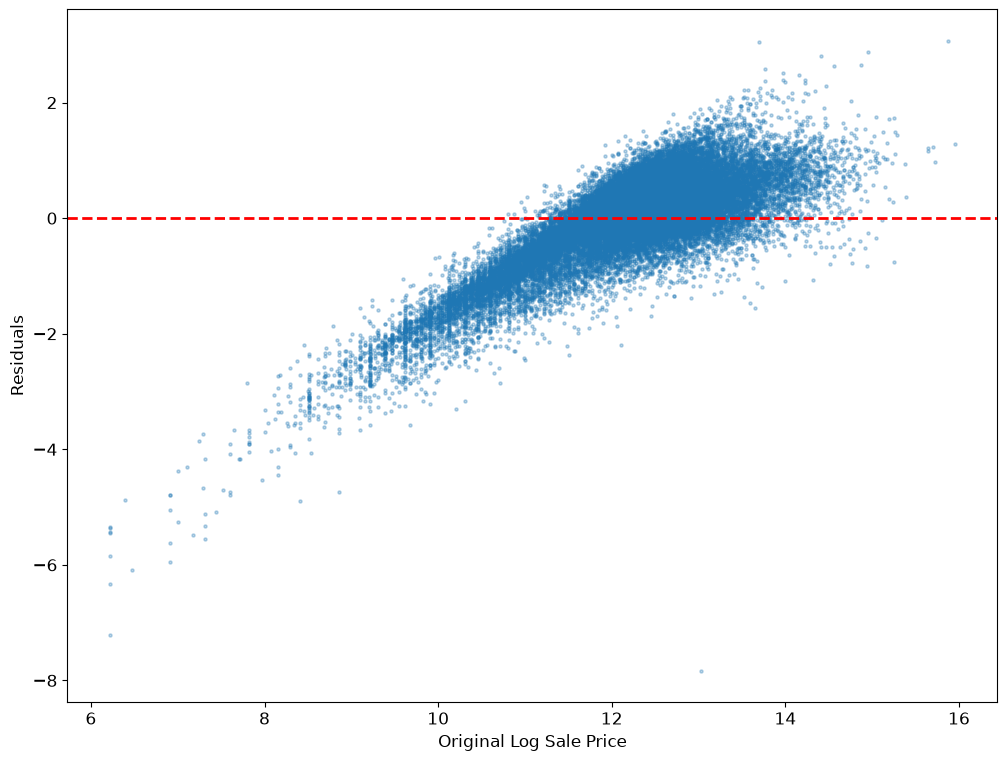

In [15]:
plt.scatter(Y_valid_m2, Y_valid_m2 - Y_predicted_m2, s=5, alpha=0.3)
plt.xlabel("Original Log Sale Price")
plt.ylabel("Residuals")
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.show()

<!-- END QUESTION -->

<br>

--- 
### Plot Analysis
Earlier, We examined the structure of residual plot for each taxation type (i.e regressive, progressive, proportional).
This residual plot has a positive slope.
Based on the observed structure in the plot, this model appears to correspond to _regressive_ taxation.

<br>

--- 

### RSME Calculation of Simple Model Through CV (part 1)

`k`-fold cross validation (CV) enables more accurate evaluation of the models than a single train-validation split. In `k`-fold CV, every data point is used in model training at some point. 

In this notebook, we will use `k`-fold cross validation to generate `k` estimates of the test set RMSE. These `k` RMSEs might be helpful when deciding between models.   

The helper functions `compute_CV_error`:
1. Use `sklearn`'s `KFold.split` ([documentation](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html))  function to generate `k` splits of the training data. Note that `KFold.split` returns the indices of the data for each split.
2. For **each** split:
    1. Assign the folds to training and validation based on the split indices and desired features.
    2. Train the model on the training folds, and compute the RMSE on the validation fold.
3. Finally, return a **list** of the RMSEs computed for each validation fold. 

In [16]:
from sklearn.model_selection import KFold

def compute_CV_error(X_train, Y_train, folds=4):
    """
    Split the training data into `k` subsets.
    For each subset, 
        - Fit a model holding out that subset.
        - Compute the MSE on that subset (the validation set).
    You should be fitting `k` models in total.
    Return a list of `k` RMSEs.

    Args:
        model: An sklearn model with fit and predict functions. 
        X_train (DataFrame): Training data.
        Y_train (Series): Label.
    
    Return:
         A list of `k` RMSEs.
    """
    model = lm.LinearRegression(fit_intercept=True)
    kf = KFold(n_splits=folds)

    validation_errors = []
    
    for train_idx, valid_idx in kf.split(X_train):
        # Split the data
        split_X_train, split_X_valid = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        split_Y_train, split_Y_valid = Y_train.iloc[train_idx], Y_train.iloc[valid_idx]

        # Fit the model on the training split
        model.fit(split_X_train, split_Y_train)
        Y_predicted = model.predict(split_X_valid)

        
        # Compute the RMSE on the validation split
        error = rmse(Y_predicted, split_Y_valid)


        validation_errors.append(error)

    return validation_errors

<br>

--- 

### RSME Calculation of Simple Model Through CV (part 2)

Use `compute_CV_error` to generate two lists of RMSEs generated by 4-fold cross validation: one list for Model 1 and one list for Model 2. Assign these lists to `cv_m1` and `cv_m2`, respectively. 

In [17]:
from sklearn.model_selection import KFold

np.random.seed(1337)

X_train_m1_cv, Y_train_m1_cv = feature_engine_pipe(full_data, m1_pipelines, 'Log Sale Price')
X_train_m2_cv, Y_train_m2_cv = feature_engine_pipe(full_data, m2_pipelines, 'Log Sale Price')

cv_m1 = compute_CV_error(X_train_m1_cv, Y_train_m1_cv, 4)
cv_m2 = compute_CV_error(X_train_m2_cv, Y_train_m2_cv, 4)
print(f"The RMSE errors for 4-fold cross-validation on Model 1 were: {cv_m1}")
print(f"The RMSE errors for 4-fold cross-validation on Model 2 were: {cv_m2}")

The RMSE errors for 4-fold cross-validation on Model 1 were: [np.float64(0.8428096644792091), np.float64(0.8391295101697527), np.float64(0.849439435356886), np.float64(0.8577760985197012)]
The RMSE errors for 4-fold cross-validation on Model 2 were: [np.float64(0.7954578405137172), np.float64(0.7942711383610485), np.float64(0.7975076199867488), np.float64(0.8106935087319972)]


While the simple model explains some of the variability in price, there is certainly still a lot of room for improvement —— one reason is we have been only using 1 or 2 features (out of a total of 70+)! In the next part, we will engineer and incorporate more features to improve the model's fairness and accuracy.

<br>

<hr style="border: 1px solid #fdb515;" />

# 5. Build Higher Dimension Regression Model

Outline:

1. Conduct feature engineering on the training data using the `feature_engine_final` function, then fit and evaluate the model with the training data.

2. Process the test data with `feature_engine_final`, use the trained model to predict `Log Sale Price` for the test data, transform the predicted and original log-dollar values back to the dollar scale (by using `delog`), and compute the test RMSE.

Error Interpretation: 
- An RMSE of 1 on the natural log scale is equivalent to a typical **multiplicative error** of $e \approx 2.718$. 

- In other words, an RMSE of 1 on the log scale could be *roughly* interpreted as follows: Typically, the predictions are different from actual prices by a factor of 2.718. 

- Example intuition: Let's say for one data point the actual home price is $e^{12} \approx \$162,500$. The predicted home price is $e^{13} \approx 442,000$. On the log scale, the actual home price is 12, and the predicted price is 13. So, the log error is 1. This is equivalent to a multiplicative error of $\frac{\$442,000}{\$162,500} \approx e \approx 2.718$. 

<br>

---

### Finding Potential Features

The followings are some features inferred to be helpful in `Sales Price` prediction, based on the documentation about the dataset in `codebook.txt`.

The features related to property size are likely to be positively correlated with the housing price. These include:
- `Building Square Feet`
- `Land Square Feet`
- `Lot Size`
- `Garage 1 Size`

The `Age` is likely to be negatively correlated with the housing price



<br>

---

### More EDA

Some potential ideas:
    
* Plot the distribution of a variable. Is this variable heavily skewed? Are there any outliers? This can inform how you engineer your features later on.

* Make a scatter plot between quantitative features and the outcomes. Is there a relationship? Is there a transformation that may linearize the relationship?

* Make a plot of a qualitative feature and the outcome. Is there a relationship? How can we transform this categorical data into numerical features that can be useful for OLS?

* Find the correlation coefficient between features and the outcome. Is there a strong relationship between the two? Can you find the correlation coefficient between different transformations of the feature and the outcome?

</details>

In [18]:
# Add any EDA code below
# Possible features: Building Square Feet, Land Square Feet, Lot Size, Age
full = pd.read_csv("cook_county_train.csv")
full.head(3)

,Unnamed: 0,PIN,Property Class,Neighborhood Code,Land Square Feet,Town Code,Apartments,Wall Material,Roof Material,Basement,...,Sale Month of Year,Sale Half of Year,Most Recent Sale,Age Decade,Pure Market Filter,Garage Indicator,Neigborhood Code (mapping),Town and Neighborhood,Description,Lot Size
0,0,17294100610000,203,50,2500.0,76,0.0,2.0,1.0,1.0,...,9,2,1.0,13.2,0,0.0,50,7650,"This property, sold on 09/14/2015, is a one-st...",2500.0
1,1,13272240180000,202,120,3780.0,71,0.0,2.0,1.0,1.0,...,5,1,1.0,9.6,1,1.0,120,71120,"This property, sold on 05/23/2018, is a one-st...",3780.0
2,2,25221150230000,202,210,4375.0,70,0.0,2.0,1.0,2.0,...,2,1,0.0,11.2,1,1.0,210,70210,"This property, sold on 02/18/2016, is a one-st...",4375.0


In [19]:
selected_cols = ["Sale Price", "Building Square Feet", "Land Square Feet", "Lot Size", "Age", "Garage 1 Size"]
filtered_df = full[selected_cols]
filtered_df.describe()

,Sale Price,Building Square Feet,Land Square Feet,Lot Size,Age,Garage 1 Size
count,2.047920e+05,204792.000000,2.047920e+05,2.047920e+05,204792.000000,204792.000000
mean,2.451646e+05,1617.322967,7.809451e+03,7.809451e+03,65.981210,2.374497
std,3.628694e+05,853.792871,1.525110e+04,1.525110e+04,29.001488,1.306122
min,1.000000e+00,392.000000,1.697381e+02,1.697381e+02,1.000000,0.000000
25%,4.520000e+04,1066.000000,3.810000e+03,3.810000e+03,51.000000,1.000000
50%,1.750000e+05,1324.000000,5.775000e+03,5.775000e+03,62.000000,3.000000
75%,3.120000e+05,1913.000000,8.515000e+03,8.515000e+03,89.000000,3.000000
max,7.100000e+07,23909.000000,2.980767e+06,2.980767e+06,172.000000,7.000000


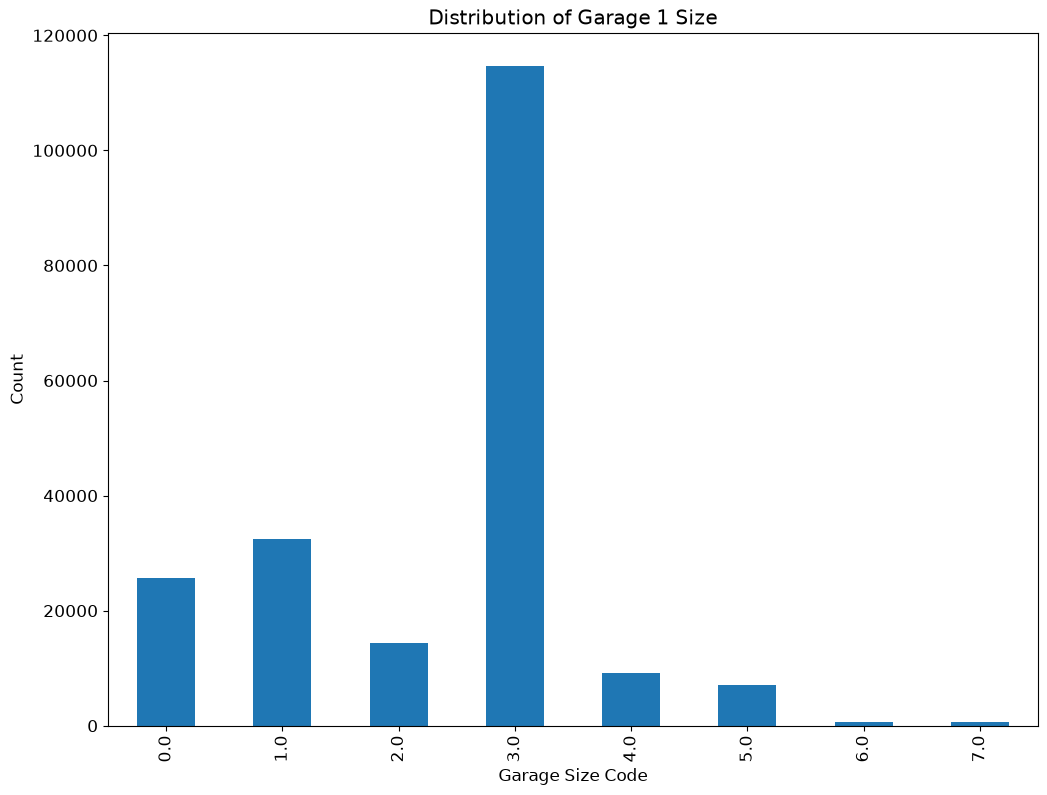

In [20]:
# Histogram of Garage 1 Size
filtered_df['Garage 1 Size'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Garage 1 Size")
plt.xlabel("Garage Size Code")
plt.ylabel("Count")
plt.show()


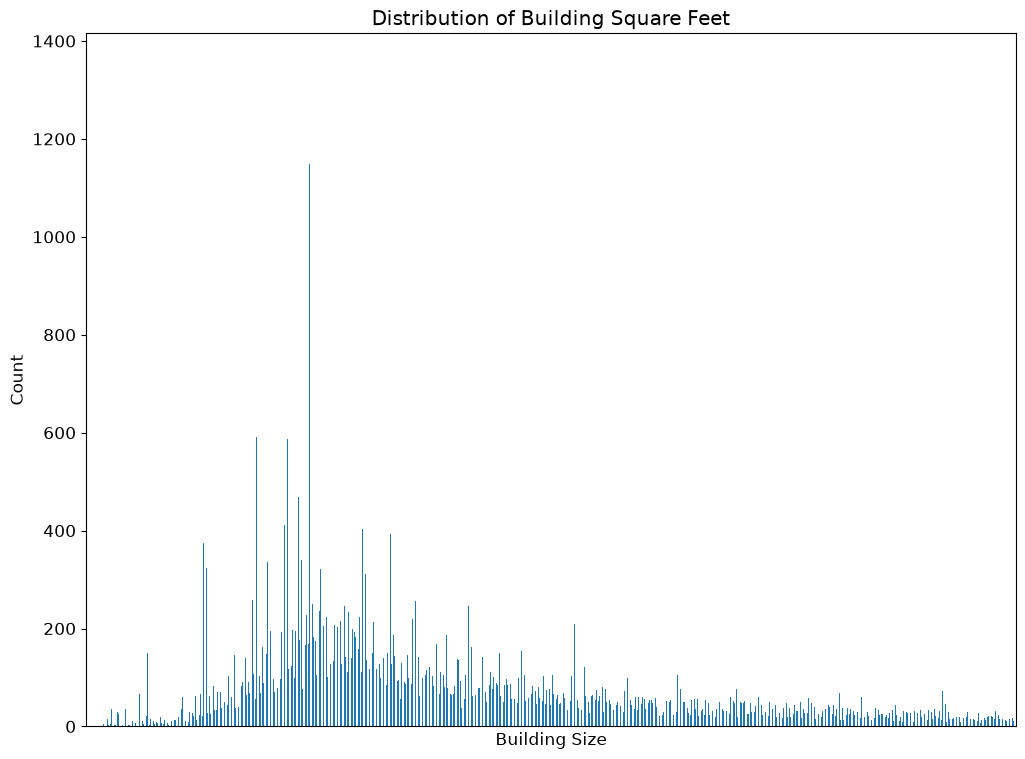

In [39]:
# Histogram of Building Square Feet
remove_outlier_df = remove_outliers(filtered_df, "Building Square Feet", lower=392, upper=3000)
remove_outlier_df["Building Square Feet"].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Building Square Feet")
plt.xticks([])
plt.xlabel("Building Size")
plt.ylabel("Count")
plt.show()


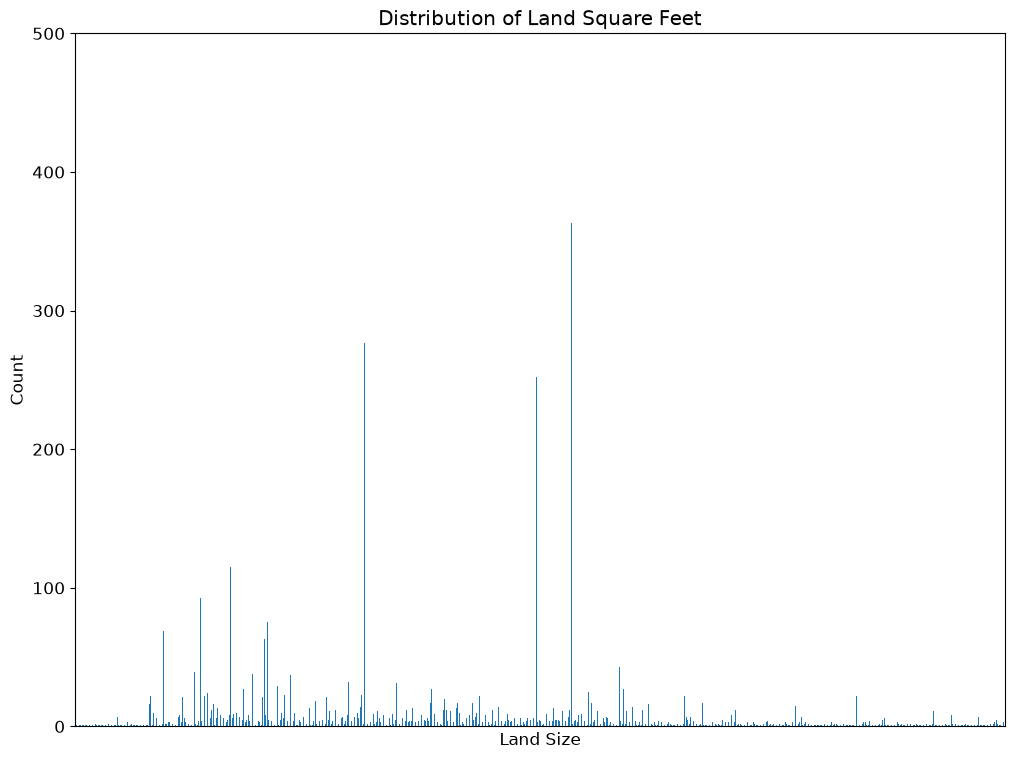

In [51]:
# Histogram of Lot Size
remove_outlier_df = remove_outliers(filtered_df, "Land Square Feet", lower=0, upper=30000)
remove_outlier_df["Land Square Feet"].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Land Square Feet")
plt.xticks([])
plt.xlabel("Land Size")
plt.ylabel("Count")
plt.ylim(0, 500)
plt.show()

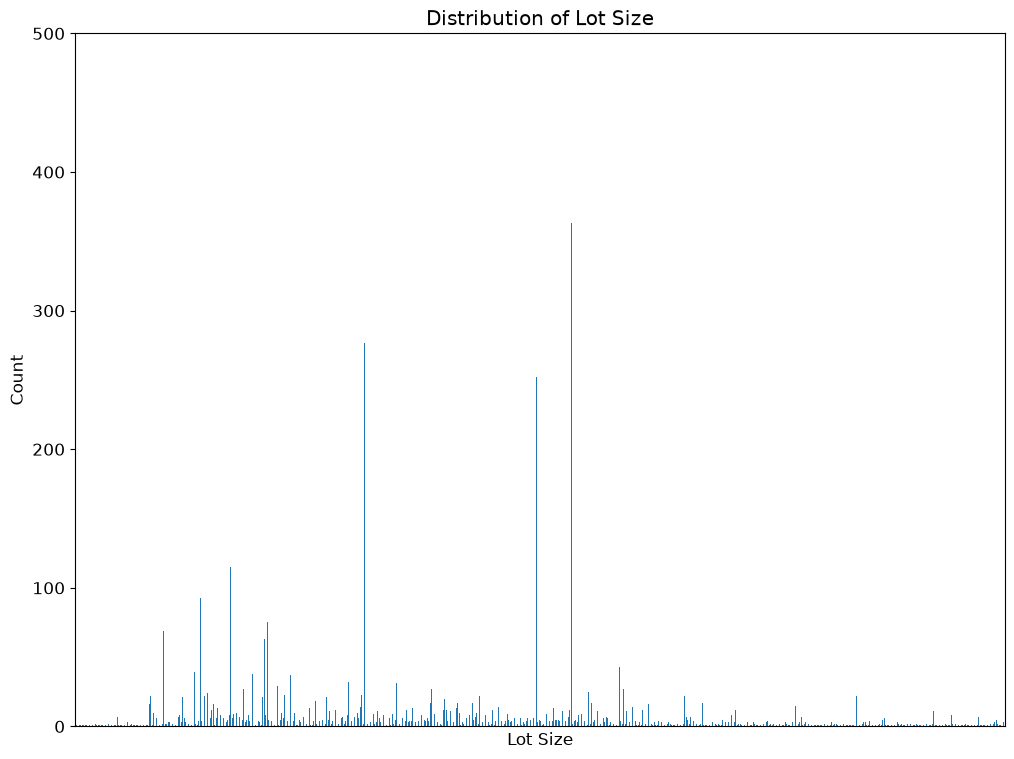

In [67]:
# Histogram of Land Square Feet
remove_outlier_df = remove_outliers(filtered_df, "Lot Size", lower=0, upper=30000)
remove_outlier_df["Lot Size"].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Lot Size")
plt.xticks([])
plt.xlabel("Lot Size")
plt.ylabel("Count")
plt.ylim(0, 500)
plt.show()

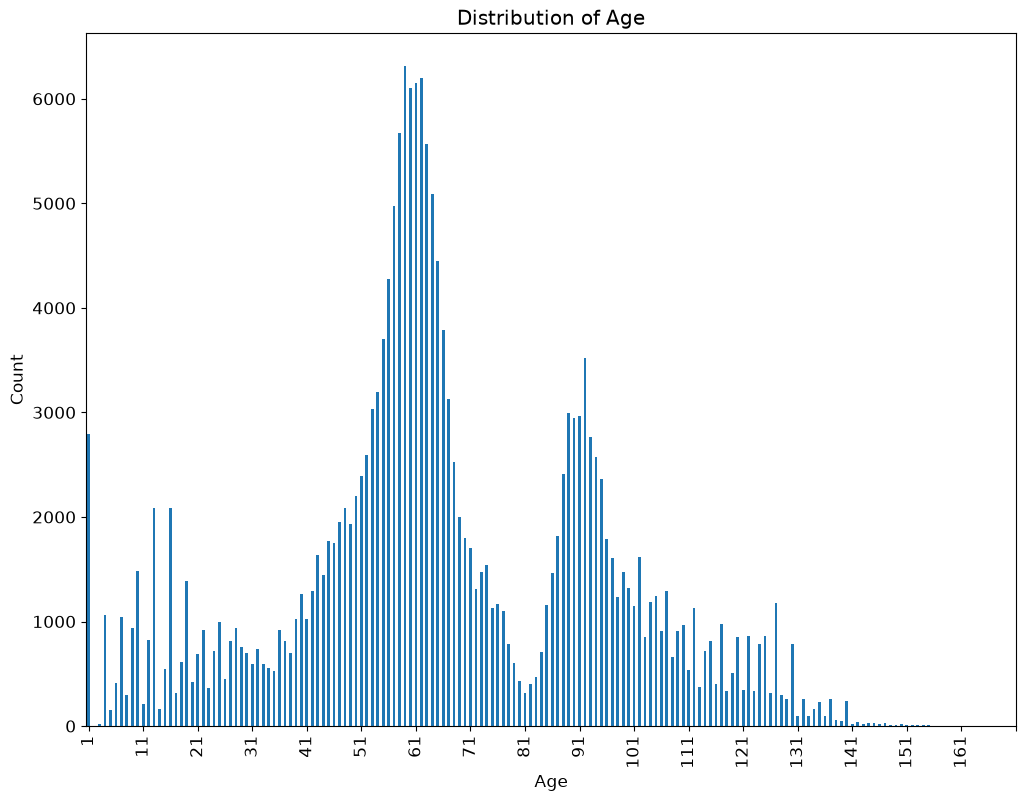

In [58]:
# Histogram of Land Square Feet
remove_outlier_df = remove_outliers(filtered_df, "Age")
remove_outlier_df["Age"].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Age")
plt.xticks(np.arange(0, 172, 10))
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

<br>

---

### Defining The Pipeline Function

Better features are selected and have defined own feature engineering pipeline inside the function `feature_engine_final`

Function Specification:
- Any feature engineering techniques that involve referencing `Sale Price` or `Log Sale Price` (for example, removing outlying `Sale Price` values from the training data) should be performed under the condition `if not is_test_set:`, which is provided in the cell below.
- All other feature engineering techniques should be applied to both the training and test sets. This means that you should perform them under the condition `else:`, provided in the cell below.
- When `is_test_set` is `True`, the function should return only the design matrix, `X`.
- When `is_test_set` is `False`, the function should return both the design matrix and the response variable `Y` (the `Log Sale Price` column).

In [91]:
def feature_engine_final(data, is_test_set=False):
    # Whenever you access 'Log Sale Price' or 'Sale Price', make sure to use the
    # condition is_test_set like this:
    if not is_test_set:
        # Processing for the training set (i.e. not the test set)
        data = remove_outliers(data, variable='Sale Price', lower=499)
        data['Log Sale Price'] = np.log(data['Sale Price'])
        
        
    # Processing for both test and training set
    data = add_total_bathrooms(data)
    
    data = log_transform(data, col="Building Square Feet")
    data = log_transform(data, col="Land Square Feet")
    data = log_transform(data, col="Lot Size")

    
    expensive_neighborhoods = find_expensive_neighborhoods(data, n=10, metric=np.median)
    data = add_in_expensive_neighborhood(data, expensive_neighborhoods)

    for col in ['Log Building Square Feet', 'Log Land Square Feet', 'Log Lot Size', 'Bathrooms', 'Age']:
        median_val = data[col].median()
        data[col] = data[col].fillna(median_val)

    features = ['Log Building Square Feet', "Log Land Square Feet", "Log Lot Size", "Bathrooms", "Age", "in_expensive_neighborhood"]
    
    # Return predictors (X) and response (Y) variables separately
    if not is_test_set:
        X = data[features]
        Y = data['Log Sale Price']
        return X, Y
        
    else:
        # Predictors 
        X = data[features]
        return X

check_rmse_threshold = run_linear_regression_test_optim(lm.LinearRegression(fit_intercept=True), feature_engine_final, 'cook_county_train.csv', None, False)
print("Current training RMSE:", check_rmse_threshold.loss)

Current training RMSE: 0.797059970956351


<br>

---

### Fit and Evaluate the Complex Model

Use a `sklearn` default `LinearRegression()` model with intercept term. 

It may also be helpful to calculate the RMSE directly as follows:

$$RMSE = \sqrt{\dfrac{\sum_{\text{houses in the set}}(\text{actual log price for house} - \text{predicted log price for house})^2}{\text{number of houses}}}$$

We cannot compute test RMSE directly since we do not have the observed values. Perform cross-validation (feel free to use compute_CV_error) to estimate the test error. Recall that we are treating the validation set as unseen data.

In [93]:
def rmse(predicted, actual):
    """
    Calculates RMSE from actual and predicted values.
    Input:
      predicted (1D array): Vector of predicted/fitted values
      actual (1D array): Vector of actual values
    Output:
      A float, the RMSE value.
    """
    return np.sqrt(np.mean((actual - predicted)**2))

In [95]:
np.random.seed(1337)

X_train_mc_cv, Y_train_mc_cv = feature_engine_final(full)

cv_mc = compute_CV_error(X_train_m1_cv, Y_train_m1_cv, 4)
print(f"The AVG RMSE errors for 4-fold cross-validation on the Complex Model were: {np.mean(cv_m1)}")

The AVG RMSE errors for 4-fold cross-validation on the Complex Model were: 0.7971131702297369


<br>

<hr style="border: 1px solid #fdb515;" />

## 🫚 6. Exploring RMSE

We will explore what RMSE means in the context of predicting house prices. We will go through different ways of visualizing the performance the model and see how it relates to questions about property taxes.

<br>

---

In [96]:
# Run the cell below; no further action is needed
train_df = pd.read_csv('cook_county_train.csv')
X, Y_true = feature_engine_final(train_df)
model = lm.LinearRegression(fit_intercept=True)
model.fit(X, Y_true)
Y_pred = model.predict(X)

In [97]:
preds_df = pd.DataFrame({'True Log Sale Price' : Y_true, 'Predicted Log Sale Price' : Y_pred, 
                         'True Sale Price' : np.e**Y_true, 'Predicted Sale Price' : np.e**Y_pred})
preds_df.head()

,True Log Sale Price,Predicted Log Sale Price,True Sale Price,Predicted Sale Price
1,12.560244,11.607521,285000.0,109921.420049
2,9.998798,11.495415,22000.0,98264.213488
3,12.323856,11.892831,225000.0,146214.607518
4,10.025705,11.568079,22600.0,105670.240720
6,11.512925,12.264131,100000.0,211955.286263


<br>

---
### Model Performace on Houses with Cheaper Price vs Expensive Price

Let's examine how our model performs on two halves of our data: `cheap_df`, which contains the rows of `preds_df` with prices below or equal to the median sale price, and `expensive_df`, which has rows of `preds_df` with true sale prices above the median. 

In [ ]:
min_Y_true, max_Y_true = np.round(np.min(Y_true), 1) , np.round(np.max(Y_true), 1)
median_Y_true = np.round(np.median(Y_true), 1)
cheap_df = preds_df[(preds_df['True Log Sale Price'] >= min_Y_true) & (preds_df['True Log Sale Price'] <= median_Y_true)]
expensive_df = preds_df[(preds_df['True Log Sale Price'] > median_Y_true) & (preds_df['True Log Sale Price'] <= max_Y_true)]

print(f'\nThe lower interval contains houses with true sale price ${np.round(np.e**min_Y_true)} to ${np.round(np.e**median_Y_true)}')
print(f'The higher interval contains houses with true sale price ${np.round(np.e**median_Y_true)} to ${np.round(np.e**max_Y_true)}\n')


The lower interval contains houses with true sale price $493.0 to $219696.0
The higher interval contains houses with true sale price $219696.0 to $72565488.0



**Compute the RMSE of the complex model's predictions of `Sale Price` (i.e., the exponentiated version of `Log Sale Price`) on `cheap_df` and `expensive_df` separately**. Assign these RMSE values to `rmse_cheap` and `rmse_expensive`, respectively.

Then, compute the proportion of houses in `cheap_df` and `expensive_df` for which the model overestimates `Sale Price`. Assign the proportions to `prop_overest_cheap` and `prop_overest_expensive`, respectively. 

- For example, if we were working with a dataset of 3 houses where the actual `Log Sale Price`s were [10, 11, 12] and the model predictions were [5, 15, 13], then the proportion of houses with overestimated values would be 2/3.

**Note:** As mentioned before, even though it is not mathematically correct to compare the RMSE in sale price—since we trained the model using log sale price—it still provides some insight into the dataset and our model.

In [99]:
rmse_cheap = rmse(cheap_df["Predicted Sale Price"], cheap_df["True Sale Price"])
rmse_expensive = rmse(expensive_df["Predicted Sale Price"], expensive_df["True Sale Price"])

prop_overest_cheap = cheap_df[cheap_df["True Sale Price"] < cheap_df["Predicted Sale Price"]].shape[0] / cheap_df.shape[0]
prop_overest_expensive = expensive_df[expensive_df["True Sale Price"] < expensive_df["Predicted Sale Price"]].shape[0] / expensive_df.shape[0]

print(f"The RMSE for properties with log sale prices in the interval {(min_Y_true, median_Y_true)} is {np.round(rmse_cheap)}")
print(f"The RMSE for properties with log sale prices in the interval {(median_Y_true, max_Y_true)} is {np.round(rmse_expensive)}\n")
print(f"The percentage of overestimated values for properties with log sale prices in the interval {(min_Y_true, median_Y_true)} is {np.round(100 * prop_overest_cheap, 2)}%")
print(f"The percentage of overestimated values for properties with log sale prices in the interval {(median_Y_true, max_Y_true)} is {np.round(100 * prop_overest_expensive, 2)}%")

The RMSE for properties with log sale prices in the interval (np.float64(6.2), np.float64(12.3)) is 94440.0
The RMSE for properties with log sale prices in the interval (np.float64(12.3), np.float64(18.1)) is 1886239.0

The percentage of overestimated values for properties with log sale prices in the interval (np.float64(6.2), np.float64(12.3)) is 63.31%
The percentage of overestimated values for properties with log sale prices in the interval (np.float64(12.3), np.float64(18.1)) is 18.69%


#### RMSE Examination:
- The higher rsme_cheap suggests that complex model systematically makes more error for cheaper housing (or the lower income demographics).
- And the system seems to more frequently overestimate the cheaper housing, suggesting a regressive taxation. This disbenefits the lower income demographics. 

<br>

---
### Question 6b

The intervals we defined above are broad. Let's try and take a more fine-grained approach to understand how RMSE of sale price and proportion of houses overestimated vary across different intervals of `Log Sale Price`. 

The functions `rmse_interval` and `prop_overest_interval` compute the RMSE of **sale price (NOT log sale price)** and proportion of overestimated home prices for any interval of home prices, respectively. In the cell below, complete the implementation of these two function.

Pay close attention to the function descriptions, and feel free to reuse and modify the code you wrote in the previous part as needed.

**Note:** The autograder tests provided for each of the functions are **not** comprehensive as the outputs of the function are highly dependent on your model. Make sure that the values you obtain are interpretable and that the plots in 6c look appropriate.

In [237]:
def rmse_interval(df, start, end):
    """
    Given a design matrix X and response vector Y, computes the RMSE for a subset of values 
    wherein the corresponding Log Sale Price lies in the interval [start, end].

    Input: 
    df : pandas DataFrame with columns 'True Log Sale Price', 
        'Predicted Log Sale Price', 'True Sale Price', 'Predicted Sale Price'
    start : A float specifying the start of the interval (inclusive)
    end : A float specifying the end of the interval (inclusive)
    """

    subset_df = df[(df["True Log Sale Price"] >= start) & (df["True Log Sale Price"] < end)]

    rmse_subset = rmse(subset_df["Predicted Sale Price"], subset_df["True Sale Price"])
    return rmse_subset
    
def prop_overest_interval(df, start, end):
    # """
    # Given a DataFrame df, computes prop_overest for a subset of values 
    # wherein the corresponding Log Sale Price lies in the interval [start, end].

    # Input: 
    # df : pandas DataFrame with columns 'True Log Sale Price', 
    #     'Predicted Log Sale Price', 'True Sale Price', 'Predicted Sale Price'
    # start : A float specifying the start of the interval (inclusive)
    # end : A float specifying the end of the interval (inclusive)
    # """
    
    subset_df = df[(df["True Log Sale Price"] >= start) & (df["True Log Sale Price"] < end)]

    # DO NOT MODIFY THESE TWO LINES
    if subset_df.shape[0] == 0:
        return -1

    prop_subset = subset_df[subset_df["True Sale Price"] < subset_df["Predicted Sale Price"]].shape[0] / subset_df.shape[0]
    return prop_subset

In [238]:
grader.check("q6b")

q6b results: All test cases passed!

<!-- BEGIN QUESTION -->

<br>

---
### Question 6c

Using the functions above, we can generate visualizations of how the RMSE of sale price and proportion of overestimated houses vary for different intervals:

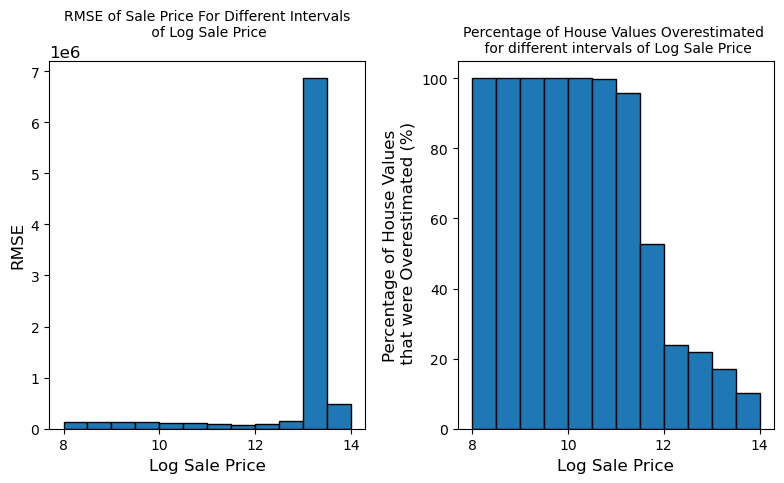

In [239]:
# RMSE plot
plt.figure(figsize = (8,5))
plt.subplot(1, 2, 1) 
rmses = []
for i in np.arange(8, 14, 0.5):
    rmses.append(rmse_interval(preds_df, i, i + 0.5))
plt.bar(x = np.arange(8.25, 14.25, 0.5), height = rmses, edgecolor = 'black', width = 0.5)
plt.title('RMSE of Sale Price For Different Intervals\n of Log Sale Price', fontsize = 10)
plt.xlabel('Log Sale Price')
plt.yticks(fontsize = 10)
plt.xticks(fontsize = 10)
plt.ylabel('RMSE')

# Overestimation plot  
plt.subplot(1, 2, 2)
props = []
for i in np.arange(8, 14, 0.5):
    props.append(prop_overest_interval(preds_df, i, i + 0.5) * 100) 
plt.bar(x = np.arange(8.25, 14.25, 0.5), height = props, edgecolor = 'black', width = 0.5)
plt.title('Percentage of House Values Overestimated \n for different intervals of Log Sale Price', fontsize = 10)
plt.xlabel('Log Sale Price')
plt.yticks(fontsize = 10)
plt.xticks(fontsize = 10)
plt.ylabel('Percentage of House Values\n that were Overestimated (%)')

plt.tight_layout()
plt.show()

Which of the two plots above would be more useful in ascertaining whether the assessments tended to result in progressive or regressive taxation? Provide a brief explanation to support your choice of plot.

Then, explain whether your chosen plot aligns more closely aligns with scenario C or scenario D from `q1b`: 

    C. An assessment process that systematically overvalues inexpensive properties and undervalues expensive properties.  
    D. An assessment process that systematically undervalues inexpensive properties and overvalues expensive properties.

*Your response should be approximately 3 to 4 sentences.*

The second plot however directly shows where the overestimation occurred along the log sale price, giving useful information on the model is progessive (if more overvaluations on higher price then progressive taxation) or regressive (if more overvaluations on lower price then regressive taxation). Since the proportion of overestimation occured more on the lower price and and less on higher price, it suggests a scenario C. In contrast, the error metric RMSE squares the residual, the first plot only show that how much error occured at the given log sale price, but not giving any information on the direction of the error.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

<hr style="border: 1px solid #fdb515;" />

## 🕵️ Question 7: Evaluating the Model in Context

<br>

---
## Question 7a

When evaluating your model, we used RMSE. In the context of estimating the value of houses, what does the residual mean for an individual homeowner? How does a positive or negative residual affect them in terms of property taxes? Discuss the cases where the residual is positive and negative separately.

*Your response should be approximately 2 to 4 sentences.*

Technically in terms of the model, the residual mean the difference of true sale price of the houses (its market value) by the one predicted by the model. More contextually, in perspective of homeowner, the residual is what determines if they have to pay more or less property tax. In specifc, negative residual means overvaluation of their property (prediction is larger than the actual), so the corresponding property tax would unfairly increase, higher than the true property tax. Other hand, positive residual means undervaluation of their property (prediction is smaller than the actual), so the corresponding property tax would decrease, lower than the true property tax.  

<!-- END QUESTION -->

In the case of the Cook County Assessor’s Office, Chief Data Officer Rob Ross states that fair property tax rates are contingent on whether property values are assessed accurately —— that they’re valued at what they’re worth, relative to properties with similar characteristics. This implies that having a more accurate model results in fairer assessments. The goal of the property assessment process for the CCAO, then, is to be as accurate as possible. 

When the use of algorithms and statistical modeling has real-world consequences, we often refer to the idea of fairness as a measurement of how socially responsible our work is. Fairness is incredibly multifaceted: Is a fair model one that minimizes loss - one that generates accurate results? Is it one that utilizes "unbiased" data? Or is fairness a broader goal that takes historical contexts into account?

These approaches to fairness are not mutually exclusive. If we look beyond error functions and technical measures of accuracy, we'd not only consider _individual_ cases of fairness but also what fairness —— and justice —— means to marginalized communities on a broader scale. We'd ask: What does it mean when homes in predominantly Black and Hispanic communities in Cook County are consistently overvalued, resulting in proportionally higher property taxes? When the white neighborhoods in Cook County are consistently undervalued, resulting in proportionally lower property taxes? 

Having "accurate" predictions doesn't necessarily address larger historical trends and inequities, and fairness in property assessments in taxes works beyond the CCAO's valuation model. Disassociating accurate predictions from a fair system is vital to approaching justice at multiple levels. Take Evanston, IL —— a suburb in Cook County —— as an example of housing equity beyond just improving a property valuation model: their City Council members [recently approved reparations for African American residents](https://www.usnews.com/news/health-news/articles/2021-03-23/chicago-suburb-approves-government-reparations-for-black-residents).


<!-- BEGIN QUESTION -->

<br>

---

## Question 7b

Reflecting back on your exploration in Questions 6 and 7a, in your own words, what makes a model's predictions of property values for tax assessment purposes "fair"? 

This question is open-ended and part of your answer may depend on your specific model; we are looking for thoughtfulness and engagement with the material, not correctness. 

**Hint:** Some guiding questions to reflect on as you answer the question above: What is the relationship between RMSE, accuracy, and fairness as you have defined it? Is a model with a low RMSE necessarily accurate? Is a model with a low RMSE necessarily "fair"? Is there any difference between your answers to the previous two questions? And if so, why?

*Your response should be approximate 1 to 2 paragraphs. Feel free to answer the questions in the hint to structure your answer.*

What makes a fair model? In this case, it is important to note that fairness doesn't equal accuracy. I defined accuracy as more numerical that seperates itself to the context of the model being applied on. This could be lowering the overall RMSE. Then does it necessarily mean the model with low RMSE (in other word accurate model) is unbiased? The plot from the Q6 disproves this. The strategy of the feature engineering combined with fairly complex OLS model produce dencently low RMSE , but it showed a clealy biased pattern, in which the oversestimation was occuring signicantly higher for lower sale price and vulnerable population. If the more theorical accuracy does not solve social issue at hand, what do we need to consider. This is where my definition of the fairness come in. I define fair as a higher meaning that brings accuracy (RMSE) and the social impact of the model together. So, fair model is something that produces a decently low RMSE, but more importantly creates an error where the distribution (along the sale price this amongst social group) is fairly equal and absent of any pattern targeting certain population. So fair model differs with accurate model in a way that the priority is not blindly optimizing the RMSE only, but considering what is the social meaning behind the direction and location of the erro and try to incorporate this in the optimization process. With this approach, the model would resolve the deep-rooted racial and class discrimnation underlying the property assessment where model "thinks" about the impact of each error it's making . This might be done by adding a bias or additional penality for overestimation in the lower price to mitigate the social cost. As a result, it would create a fairer, in other words, lesson the social cost.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

<hr style="border: 1px solid #fdb515;" />

## 🕵️ Question 8: Finding Better Metrics For Our Model

<br>

---

## Question 8a

As discussed in Project A1, RMSE—while a widely used and powerful error metric introduced in earlier lectures—is not always the most appropriate choice when evaluating the *fairness* of a property appraisal system. In Question 7, you already encountered some of RMSE's limitations, particularly its tendency to disproportionately emphasize errors in high-priced properties due to the squaring of residuals.

In this question, rather than relying on RMSE, we will train and evaluate our model using another custom fairness metric. Specifically, we will examine the **Mean Absolute Percentage Error (MAPE)**, which measures the average error as a percentage of the true value. This allows us to better assess whether the model is making relatively fair predictions across different segments of the housing market.

In the code cells that follow, we’ll explore how MAPE varies across price ranges—comparing the model’s relative performance on inexpensive versus expensive housing. This helps identify whether the model systematically favors or disadvantages certain groups of properties based on their price.

**Note:** You'll notice that we’re no longer using `lm.LinearRegression()`, but instead have started using `minimize`. This is because `scikit-learn` does not allow customization of the loss function in their standard linear regression model. The approach shown below provides an equivalent way to train a linear regression model using a custom error metric.

**Warning:** These cells take quite a long time to run. Please be patient, wait, and avoid restarting the kernel or rerunning these cells more than necessary.

In [240]:
data = pd.read_csv("cook_county_train.csv", index_col='Unnamed: 0')
trainX, trainY = feature_engine_final(data) 

In [241]:
# X is the design matrix (including bias column), y is the vector of true outputs, theta is the parameter vector
def mape(theta, X, y):
    y_pred = X @ theta  # compute predicted values using linear combination of features
    percentage_error = np.abs((y - y_pred) / y)  # calculate element-wise percentage errors
    return np.mean(percentage_error)  # return the MAPE

In [242]:
from scipy.optimize import minimize

# Add bias (intercept) column to the design matrix
trainX_with_bias = np.column_stack([np.ones(trainX.shape[0]), trainX])

# Initialize parameter vector with zeros
theta_0 = np.zeros(trainX_with_bias.shape[1])

# Use scipy's minimize to find weights that minimize MAPE
res = minimize(mape, theta_0, args=(trainX_with_bias, trainY), method='BFGS')

# Optimal weights after training
theta_opt = res.x

theta_opt

array([ 5.30458279,  0.95651575, -0.01922656, -0.01922643,  0.19401677,
        0.44775412])

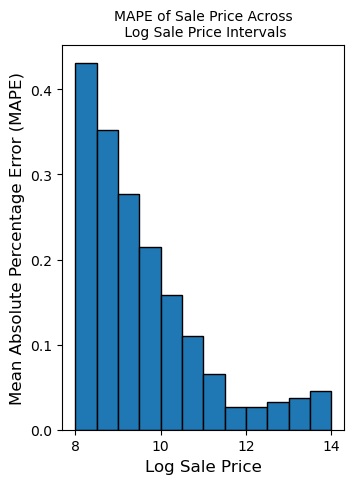

In [243]:
new_preds_df = pd.DataFrame({
    'True Log Sale Price'     : trainY,
    'Predicted Log Sale Price': trainX_with_bias @ theta_opt,
    'True Sale Price'         : np.e ** trainY,
    'Predicted Sale Price'    : np.e ** (trainX_with_bias @ theta_opt)
})

plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)

mape_values = []
for i in np.arange(8, 14, 0.5):
    mape_values.append(mape_interval(new_preds_df, i, i + 0.5))

plt.bar(x=np.arange(8.25, 14.25, 0.5), height=mape_values, edgecolor='black', width=0.5)
plt.title('MAPE of Sale Price Across\n Log Sale Price Intervals', fontsize=10)
plt.xlabel('Log Sale Price')
plt.ylabel('Mean Absolute Percentage Error (MAPE)')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10);

What can you infer from this graph using our new custom error metric?  Write your findings in the space below in three to five sentences. Consider addressing the following points:

- How does this metric differ from RMSE?  
- What is the purpose of this custom error function?  
- How does it relate to the idea of underpriced expensive housing mentioned in Question 6a?
- Why would this potentially be better than the RMSE in terms of the CCAO dataset?

MAPE captures the location  and proportionallity of the error while RMSE just reduce error in terms of overall magnitude. The purpose of this custom error is widen our insight on model performance by checking if the model is making approaximately fair error across different sale prices. So this error metric will inform, in contrast to RMSE, that the model is producing more error and perform poorly at the lower sale price as the graph suggests with its high MAPE in low log sale price. Also, the model performs better for the higher price. So with the MAPE, we can get a insight on the fact that there is systematically varying performance based on the sale price. Since the overall goal is to create a "fair" model that accounts the distribution of error amongst different racial and income group (which is assumed by the property sale price), this new error metric is more socially aware, thus better for model assessment